<a href="https://colab.research.google.com/github/Danata117/productivity-analyzer/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('Dataset.csv')

df = df.fillna(df.select_dtypes(include=[np.number]).mean())

In [34]:
df

,hours_slept,caffeine_mg,noise_level_db,task_type,work_environment,focus_score
0,7.700000,132.200000,43.5,Managerial,Co-working,54.7
1,6.800000,169.500000,42.8,Analytical,Co-working,54.3
2,6.983409,140.300000,30.6,Managerial,Co-working,57.8
3,9.300000,211.000000,45.8,Managerial,Office,67.8
4,6.600000,319.700000,25.1,Routine,Home,48.1
...,...,...,...,...,...,...
9995,9.000000,238.800000,34.2,Analytical,Cafe,61.7
9996,4.000000,337.700000,54.4,Managerial,Office,30.3
9997,5.900000,237.800000,35.0,Creative,Co-working,48.7
9998,7.700000,371.400000,21.1,Routine,Cafe,42.6


In [3]:
X = df.drop('focus_score', axis=1)
y = df['focus_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['hours_slept', 'caffeine_mg', 'noise_level_db']),
        ('cat', OneHotEncoder(), ['task_type', 'work_environment'])
    ])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2)

In [4]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train,epochs=200,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 832.7740 - mae: 21.2814 - val_loss: 34.2168 - val_mae: 4.6724
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 79.2961 - mae: 7.0119 - val_loss: 18.2278 - val_mae: 3.1766
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 64.9924 - mae: 6.3506 - val_loss: 13.6958 - val_mae: 2.6856
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 57.9288 - mae: 5.9480 - val_loss: 14.5391 - val_mae: 2.8955
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54.4783 - mae: 5.7748 - val_loss: 11.3375 - val_mae: 2.2257
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 51.6499 - mae: 5.6050 - val_loss: 10.7592 - val_mae: 2.1359
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49.3903 - mae: 5.4498 - val_loss: 14.3028 - val_mae: 2.9013
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 47.2097 - mae: 5.3373 - val_loss: 10.0588 - val_mae: 1.9950
Epoch 9/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1

In [5]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Средняя ошибка (MAE) на тесте: {mae:.2f}")

model.save('productivity_deep_model.keras')
print("Глубокая модель сохранена в 'productivity_deep_model.keras'")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.3210 - mae: 1.7734
Средняя ошибка (MAE) на тесте: 1.77
Глубокая модель сохранена в 'productivity_deep_model.keras'


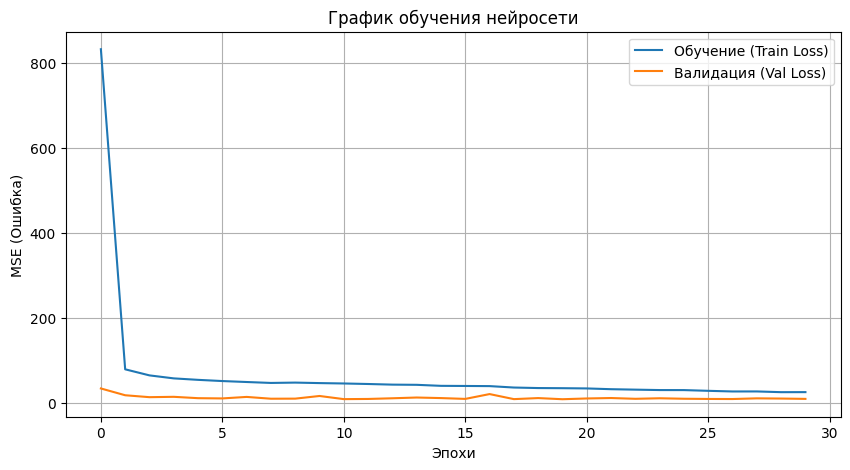

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Обучение (Train Loss)')
plt.plot(history.history['val_loss'], label='Валидация (Val Loss)')
plt.title('График обучения нейросети')
plt.xlabel('Эпохи')
plt.ylabel('MSE (Ошибка)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


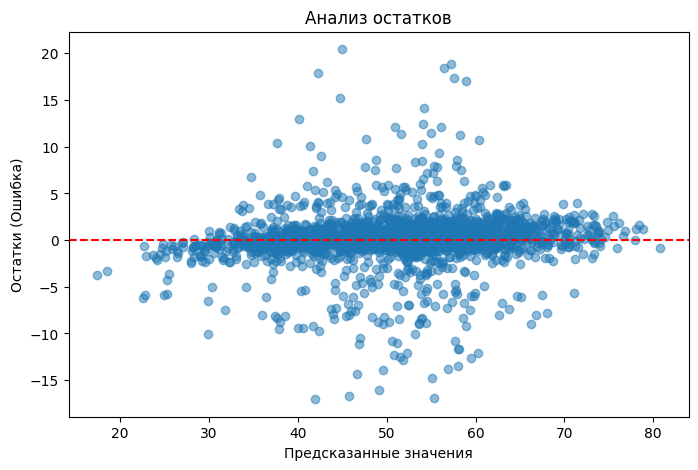

In [12]:
y_pred = model.predict(X_test).flatten()

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки (Ошибка)')
plt.title('Анализ остатков')
plt.show()

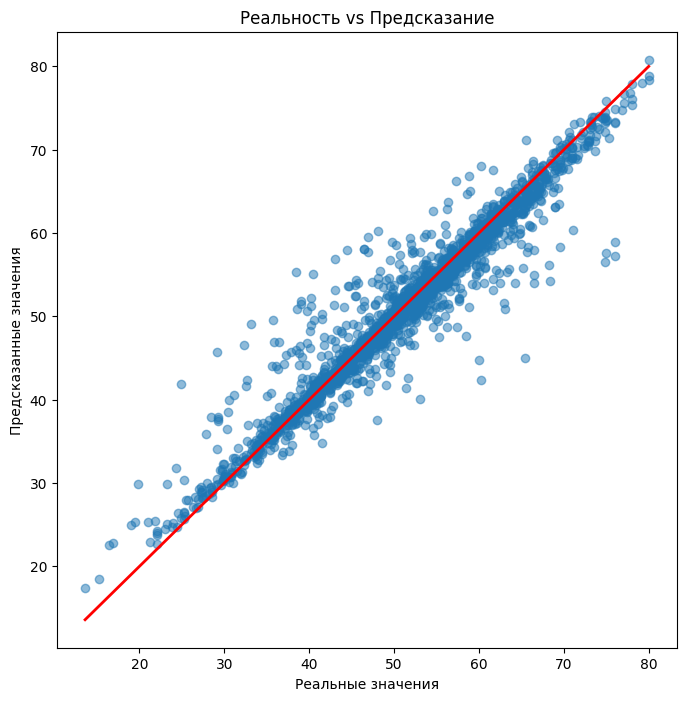

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
# Рисуем линию идеального предсказания (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Реальность vs Предсказание')
plt.show()

In [26]:
import joblib
import tensorflow as tf
import pandas as pd

model = tf.keras.models.load_model('productivity_deep_model.keras')
preprocessor = joblib.load('preprocessor.pkl')

def test_model(sleep, caffeine, noise, task, environment):
    """
    Функция для теста модели.
    Принимает значения в том виде, в котором они придут из интерфейса.
    """
    input_data = pd.DataFrame({
        'hours_slept': [sleep],
        'caffeine_mg': [caffeine],
        'noise_level_db': [noise],
        'task_type': [task],
        'work_environment': [environment]
    })

    processed_data = preprocessor.transform(input_data)

    prediction = model.predict(processed_data)

    return prediction[0][0]

result = test_model(9.0, 50.0, 80.0, 'Analytical', 'Office')

print(f"--- Результат тестирования ---")
print(f"Прогнозируемый балл продуктивности: {result:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
--- Результат тестирования ---
Прогнозируемый балл продуктивности: 56.06


In [30]:
model.save_weights('my_model_weights.weights.h5')

In [33]:
model_json = model.to_json()
with open("my_model_arch.json", "w") as json_file:
    json_file.write(model_json)
